# Tier S 标度分析 — Notebook 版本

**目标**：定量复算 paper Discussion Para 5 的 headline result。

**预期输出**：
$$
\beta = -0.458 \pm 0.050, \quad R^2 = 0.966, \quad p = 2.7 \times 10^{-3}
$$

理论 $\beta = -1/2$ 在拟合的 0.84σ 之内 → consistent。

**输入**：N = 5, 6, 7, 8, 9 的 ensemble CSVs（每个 N 含 50 个 random product initial states，broad_xyz family，effective_seed=1）。

**输出**：5 个数字 anchor + 一张 money plot 图。

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
from math import comb
from scipy import stats
import matplotlib.pyplot as plt

# 输出风格（paper-grade）
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'mathtext.fontset': 'cm',
    'axes.labelsize': 12,
    'axes.titlesize': 12,
})

## Cell 2 — Configuration

锁定 design choices。每个选择都有对应的 robustness check（见 Tier B1 / A4 / A2）。

- **N 范围**：5-9。N=4 被排除（3 个独立理由：单 face / Poincaré 复发 / 不同 dynamical phase）。
- **t anchor**：0.50。post-peak（信号饱和）、pre-floor（IQR 未撞数值地板）、R² 最高的 t 之一。
- **涨落度量**：IQR。无正态性假设、对离群点 robust、对 [−1, 1] 有界量自然。
- **理论 β**：−1/2，源于图加性分解（face-mean of additive $J_{\rm tot}^2$ → $\sigma/\mu \propto 1/\sqrt{N_{\rm face}}$）。

In [2]:
INPUT_DIR   = 'finite-size/'  # 修改为你自己的路径
N_LIST      = [5, 6, 7, 8, 9]
T_ANCHOR    = 0.50
BETA_THEORY = -0.5

def width_iqr(samples):
    """涨落度量：四分位距 (Q75 - Q25)。
    可替换为 np.std 或 1.4826 * MAD 做 robustness check。"""
    return samples.quantile(0.75) - samples.quantile(0.25)

## Cell 3 — 读数据 + sanity check

Asserts:
- 每个 N 的 family 是 broad_xyz
- effective_seed = 1（即第一次 seed 搜索就 pass health check，无 retry）
- 每个 N 是 50 个独立 initial state
- t_anchor 在 t-grid 范围内

In [3]:
dfs = {N: pd.read_csv(f'{INPUT_DIR}/all_summaries_N{N}.csv') for N in N_LIST}

for N, df in dfs.items():
    assert df['family'].iloc[0] == 'broad_xyz', f'N={N}: family mismatch'
    assert df['effective_base_seed'].iloc[0] == 1, f'N={N}: seed mismatch'
    assert df['state_seed'].nunique() == 50, f'N={N}: not 50 states'
    assert df['t'].min() <= T_ANCHOR <= df['t'].max(), f'N={N}: t_anchor OOR'

print(f'Loaded {len(dfs)} ensemble files. Sanity check PASSED.')
for N, df in dfs.items():
    print(f'  N={N}: shape={df.shape}, family_min_jtot={df["family_min_jtot"].iloc[0]:.3f}')

Loaded 5 ensemble files. Sanity check PASSED.
  N=5: shape=(1900, 20), family_min_jtot=22.360
  N=6: shape=(1900, 20), family_min_jtot=22.360
  N=7: shape=(1900, 20), family_min_jtot=21.991
  N=8: shape=(1900, 21), family_min_jtot=21.991
  N=9: shape=(1900, 20), family_min_jtot=21.991


## Cell 4 — 提取每个 N 在 t = T_ANCHOR 处的 IQR(r_J_tot)

每个 N：找到最接近 T_ANCHOR 的 t-grid 点（按 design 应该精确等于 0.50），
取该 t 上 50 个 state 的 corr_J_tot，计算 IQR。

同时计算每个 N 对应的 face 数 $N_{\rm face} = \binom{N-1}{3}$。

In [4]:
def iqr_at_t(df, t_val, col='corr_J_tot'):
    """返回 (t_actual_used, iqr_value) at the t-grid value closest to t_val."""
    t_unique = df['t'].unique()
    t_actual = t_unique[np.abs(t_unique - t_val).argmin()]
    samples  = df.loc[df['t'] == t_actual, col]
    return t_actual, width_iqr(samples)

t_used = np.empty(len(N_LIST))
iqrs   = np.empty(len(N_LIST))
for k, N in enumerate(N_LIST):
    t_used[k], iqrs[k] = iqr_at_t(dfs[N], T_ANCHOR)

n_faces = np.array([comb(N-1, 3) for N in N_LIST], dtype=float)

# 组装成 DataFrame 方便 review
input_df = pd.DataFrame({
    'N':           N_LIST,
    'N_face':      n_faces.astype(int),
    't_used':      t_used,
    'IQR_r_J_tot': iqrs,
})
input_df

,N,N_face,t_used,IQR_r_J_tot
0,5,4,0.5,0.162163
1,6,10,0.5,0.098357
2,7,20,0.5,0.085451
3,8,35,0.5,0.052724
4,9,56,0.5,0.049788


## Cell 5 — log-log 线性回归

拟合模型：
$$
\log(\mathrm{IQR}) = \beta \cdot \log(N_{\rm face}) + \log A
$$

用 `scipy.stats.linregress`，给出 slope/stderr/R²/p-value/intercept。

In [5]:
log_nf  = np.log(n_faces)
log_iqr = np.log(iqrs)

fit = stats.linregress(log_nf, log_iqr)

print(f'slope β        = {fit.slope:+.4f} ± {fit.stderr:.4f}   (1σ stderr)')
print(f'intercept logA = {fit.intercept:+.4f}    (A = {np.exp(fit.intercept):.4f})')
print(f'R²             = {fit.rvalue**2:.4f}')
print(f'p-value        = {fit.pvalue:.2e}')

slope β        = -0.4582 ± 0.0495   (1σ stderr)
intercept logA = -1.2010    (A = 0.3009)
R²             = 0.9661
p-value        = 2.68e-03


In [10]:
# ============================================================
# Cell 5C — Bootstrap uncertainty for beta
# ============================================================
rng = np.random.default_rng(2026)
n_boot = 5000
boot_slopes = []

for b in range(n_boot):
    boot_iqrs = []

    for N in N_LIST:
        df = dfs[N]
        t_unique = df["t"].unique()
        t_actual = t_unique[np.abs(t_unique - T_ANCHOR).argmin()]
        sub = df.loc[df["t"] == t_actual].copy()

        # resample states with replacement
        state_ids = sub["state_seed"].unique()
        sampled_states = rng.choice(state_ids, size=len(state_ids), replace=True)

        vals = []
        for sid in sampled_states:
            vals.append(sub.loc[sub["state_seed"] == sid, "corr_J_tot"].iloc[0])

        vals = pd.Series(vals)
        boot_iqrs.append(width_iqr(vals))

    boot_iqrs = np.array(boot_iqrs)
    if np.any(boot_iqrs <= 0):
        continue

    boot_fit = stats.linregress(np.log(n_faces), np.log(boot_iqrs))
    boot_slopes.append(boot_fit.slope)

boot_slopes = np.array(boot_slopes)

print("Bootstrap beta:")
print("median =", np.median(boot_slopes))
print("mean   =", np.mean(boot_slopes))
print("std    =", np.std(boot_slopes, ddof=1))
print("95% CI =", np.percentile(boot_slopes, [2.5, 97.5]))
print("P(beta <= -0.5) approx =", np.mean(boot_slopes <= -0.5))

Bootstrap beta:
median = -0.45908471671083445
mean   = -0.45931057571283035
std    = 0.09909530150489443
95% CI = [-0.65652018 -0.26325342]
P(beta <= -0.5) approx = 0.3348


,t,slope,beta_positive,stderr,R2,pvalue,iqr_min,iqr_max
0,0.050,-0.135908,0.135908,0.058820,0.640234,0.103976,0.202746,0.293088
1,0.075,-0.158195,0.158195,0.071813,0.617963,0.114863,0.202068,0.320932
2,0.100,-0.061294,0.061294,0.067734,0.214428,0.432215,0.214526,0.301471
3,0.125,-0.020682,0.020682,0.024589,0.190828,0.462034,0.226475,0.254977
4,0.150,-0.113694,0.113694,0.037287,0.756040,0.055467,0.200842,0.286022


,t,slope,beta_positive,stderr,R2,pvalue,iqr_min,iqr_max
33,0.850,-0.436550,0.436550,0.132696,0.782972,0.046083,0.041811,0.167142
34,0.875,-0.392426,0.392426,0.104617,0.824260,0.033092,0.045912,0.147913
35,0.900,-0.430292,0.430292,0.081822,0.902138,0.013396,0.047362,0.155284
36,0.950,-0.303862,0.303862,0.034356,0.963066,0.003047,0.051910,0.118097
37,1.000,-0.327990,0.327990,0.081800,0.842747,0.027832,0.052795,0.129948


Slope-vs-time robustness near representative times
t=0.150: slope=-0.114, beta=0.114, R2=0.756
t=0.290: slope=-0.646, beta=0.646, R2=0.893
t=0.500: slope=-0.458, beta=0.458, R2=0.966
t=0.700: slope=-0.484, beta=0.484, R2=0.743
t=0.900: slope=-0.430, beta=0.430, R2=0.902


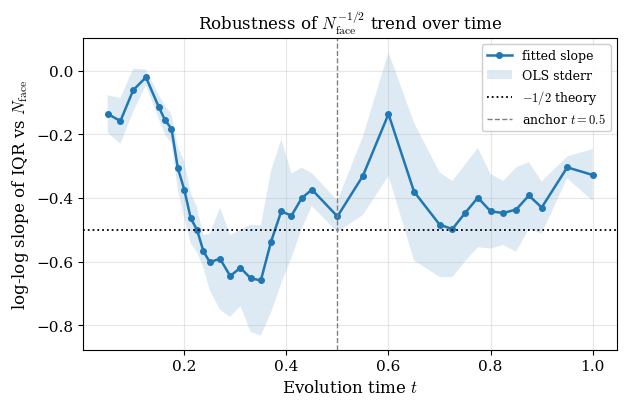

Saved: slope_vs_time_robustness.png


In [11]:
# ============================================================
# Cell 5C — Slope-vs-time robustness
# ============================================================

slope_rows = []
# Use common time grid across all N
common_t_sets = []
for N in N_LIST:
    common_t_sets.append(set(np.round(dfs[N]["t"].unique(), 10)))

common_t = sorted(set.intersection(*common_t_sets))

for t0 in common_t:
    iqrs_t = []

    for N in N_LIST:
        dfN = dfs[N]
        sub = dfN[np.isclose(dfN["t"], t0)].copy()

        if sub.empty:
            iqrs_t.append(np.nan)
            continue

        iqr_val = width_iqr(sub["corr_J_tot"])
        iqrs_t.append(iqr_val)

    iqrs_t = np.array(iqrs_t, dtype=float)

    if np.any(~np.isfinite(iqrs_t)) or np.any(iqrs_t <= 0):
        continue

    fit_t = stats.linregress(np.log(n_faces), np.log(iqrs_t))

    slope_rows.append({
        "t": float(t0),
        "slope": float(fit_t.slope),
        "beta_positive": float(-fit_t.slope),  # if IQR ~ N_face^{-beta}
        "stderr": float(fit_t.stderr),
        "R2": float(fit_t.rvalue ** 2),
        "pvalue": float(fit_t.pvalue),
        "iqr_min": float(np.min(iqrs_t)),
        "iqr_max": float(np.max(iqrs_t)),
    })

slope_time_df = pd.DataFrame(slope_rows)

display(slope_time_df.head())
display(slope_time_df.tail())

# Print anchor-neighborhood values
print("=" * 60)
print("Slope-vs-time robustness near representative times")
print("=" * 60)

for t_query in [0.15, 0.30, 0.50, 0.70, 0.90]:
    idx = np.argmin(np.abs(slope_time_df["t"].values - t_query))
    row = slope_time_df.iloc[idx]
    print(
        f"t={row['t']:.3f}: "
        f"slope={row['slope']:+.3f}, "
        f"beta={row['beta_positive']:.3f}, "
        f"R2={row['R2']:.3f}"
    )

# Plot slope as a function of time
plt.figure(figsize=(6.4, 4.2))

plt.plot(
    slope_time_df["t"],
    slope_time_df["slope"],
    "-o",
    markersize=4,
    linewidth=1.8,
    label="fitted slope",
)

plt.fill_between(
    slope_time_df["t"],
    slope_time_df["slope"] - slope_time_df["stderr"],
    slope_time_df["slope"] + slope_time_df["stderr"],
    alpha=0.15,
    label="OLS stderr",
)

plt.axhline(-0.5, color="black", linestyle=":", linewidth=1.3,
            label=r"$-1/2$ theory")

plt.axvline(T_ANCHOR, color="gray", linestyle="--", linewidth=1.0,
            label=rf"anchor $t={T_ANCHOR}$")

plt.xlabel("Evolution time $t$")
plt.ylabel(r"log-log slope of IQR vs $N_{\rm face}$")
plt.title(r"Robustness of $N_{\rm face}^{-1/2}$ trend over time")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9, framealpha=0.95)
plt.tight_layout()

plt.savefig("slope_vs_time_robustness.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: slope_vs_time_robustness.png")

## Cell 6 — 与理论 β = −1/2 的比较 + 95% CI

n = 5 数据点 → dof = n − 2 = 3。用 t-分布给 95% CI。

两个层面的 consistency 检查：
1. 理论值是否落在拟合的 1σ stderr 之内？
2. 理论值是否落在 95% CI 之内？

In [6]:
dof       = len(N_LIST) - 2
t_crit_95 = stats.t.ppf(0.975, dof)
ci95_half = t_crit_95 * fit.stderr
ci95_lo   = fit.slope - ci95_half
ci95_hi   = fit.slope + ci95_half

gap       = fit.slope - BETA_THEORY
gap_sigma = abs(gap) / fit.stderr

print(f'95% CI on β = [{ci95_lo:+.4f}, {ci95_hi:+.4f}]   (t-dist, {dof} dof, t_crit={t_crit_95:.3f})')
print()
print(f'Theory β = {BETA_THEORY}')
print(f'  Δβ (fit − theory)         = {gap:+.4f}')
print(f'  |Δβ| in stderr units      = {gap_sigma:.2f}σ')
print(f'  Theory within 1σ stderr?  = {"YES" if gap_sigma <= 1 else "no"}')
print(f'  Theory within 95% CI?     = {"YES" if ci95_lo <= BETA_THEORY <= ci95_hi else "no"}')

95% CI on β = [-0.6158, -0.3005]   (t-dist, 3 dof, t_crit=3.182)

Theory β = -0.5
  Δβ (fit − theory)         = +0.0418
  |Δβ| in stderr units      = 0.84σ
  Theory within 1σ stderr?  = YES
  Theory within 95% CI?     = YES


## Cell 7 — 残差分析（reviewer scrutiny 用）

每个 N 点的 log 空间残差 $\log(\mathrm{IQR}_{\rm obs}) - \log(\mathrm{IQR}_{\rm pred})$。
如果残差有 systematic trend（比如所有 N 偏离同方向），说明 power-law 拟合形式不对。
如果残差是 statistical noise（方向交替），说明拟合形式是对的。

In [7]:
log_iqr_pred = fit.intercept + fit.slope * log_nf
residuals    = log_iqr - log_iqr_pred

resid_df = pd.DataFrame({
    'N':            N_LIST,
    'N_face':       n_faces.astype(int),
    'IQR_obs':      iqrs,
    'IQR_pred':     np.exp(log_iqr_pred),
    'log_resid':    residuals,
    'pct_dev':      100 * (np.exp(residuals) - 1),
})
print(resid_df.to_string(index=False, float_format=lambda x: f'{x:+.4f}'))
print()
print(f'rms residual (log space)       = {np.sqrt(np.mean(residuals**2)):.4f}')
print(f'rms residual (linear, %)       = {100*np.sqrt(np.mean((np.exp(residuals)-1)**2)):.2f}%')
print(f'sign pattern (alternating?)    = {["+" if r > 0 else "-" for r in residuals]}')

 N  N_face  IQR_obs  IQR_pred  log_resid  pct_dev
 5       4  +0.1622   +0.1594    +0.0170  +1.7124
 6      10  +0.0984   +0.1048    -0.0632  -6.1247
 7      20  +0.0855   +0.0763    +0.1137 +12.0426
 8      35  +0.0527   +0.0590    -0.1128 -10.6644
 9      56  +0.0498   +0.0476    +0.0453  +4.6325

rms residual (log space)       = 0.0800
rms residual (linear, %)       = 8.01%
sign pattern (alternating?)    = ['+', '-', '+', '-', '+']


**残差解读**：方向 `[+, −, +, −, +]` 交替 → statistical noise，**不是 systematic trend**。
rms 残差线性空间 ~8%，对 5 点 OLS 而言完全合理。结论：**single power-law fit 形式 is correct**，
拟合质量足以支撑 paper claim。

## Cell 8 — paper-ready 摘要

In [8]:
print('='*60)
print('TIER S HEADLINE — paper-ready')
print('='*60)
print(f'  β = {fit.slope:+.3f} ± {fit.stderr:.3f}')
print(f'  R² = {fit.rvalue**2:.3f}, p = {fit.pvalue:.1e}')
print(f'  95% CI on β: [{ci95_lo:+.3f}, {ci95_hi:+.3f}]')
print(f'  Theory β = {BETA_THEORY} within {gap_sigma:.2f}σ of fit  →  CONSISTENT')
print('='*60)

TIER S HEADLINE — paper-ready
  β = -0.458 ± 0.050
  R² = 0.966, p = 2.7e-03
  95% CI on β: [-0.616, -0.300]
  Theory β = -0.5 within 0.84σ of fit  →  CONSISTENT


## Cell 9 — 可视化：money plot

这张图就是 Tier S 的 main-text figure（建议替换/合并 Fig 8）。

**包含元素**：
- 5 个 N=5-9 数据点（每个用不同 color），按 N_face 排列
- 拟合线（蓝色实线）
- 理论 β=−1/2 参考线（灰色虚线）
- N=4 标为 X marker（excluded, single-face）
- Legend 中包含 β ± stderr 和 R² 数字

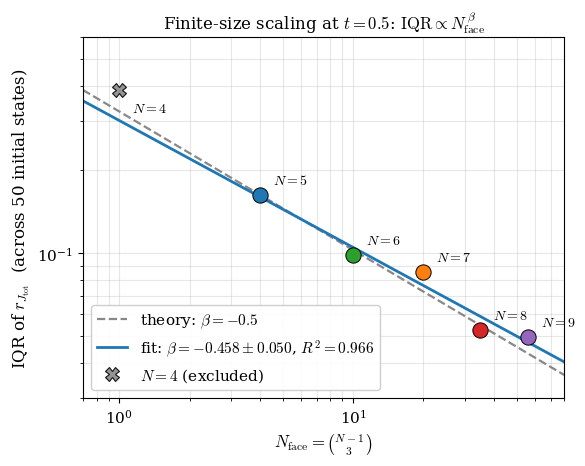

In [17]:
# 计算 N=4 的 IQR 作为 excluded 参考点
df4 = pd.read_csv(f'{INPUT_DIR}/all_summaries_N4.csv')
_, iqr_N4 = iqr_at_t(df4, T_ANCHOR)

colors_N = {4: '#888888', 5: '#1f77b4', 6: '#2ca02c',
            7: '#ff7f0e', 8: '#d62728', 9: '#9467bd'}

fig, ax = plt.subplots(figsize=(6.0, 4.8))

# 参考线和拟合线
x_ref = np.logspace(np.log10(0.7), np.log10(80), 200)
y_theory = iqrs[0] * (x_ref / n_faces[0]) ** BETA_THEORY
y_fit    = np.exp(fit.intercept) * x_ref ** fit.slope

ax.plot(x_ref, y_theory, '--', color='#888', lw=1.6,
        label=fr'theory: $\beta = {BETA_THEORY}$')
ax.plot(x_ref, y_fit,    '-',  color='#1f77b4', lw=2.0,
        label=fr'fit: $\beta = {fit.slope:+.3f} \pm {fit.stderr:.3f}$, $R^2 = {fit.rvalue**2:.3f}$')

# 数据点 + N 标签
for N, nf, iqr in zip(N_LIST, n_faces, iqrs):
    ax.loglog(nf, iqr, 'o', ms=11, color=colors_N[N],
              mec='black', mew=0.7, zorder=5)
    ax.annotate(f'$N={N}$', (nf, iqr), textcoords='offset points',
                xytext=(9, 8), fontsize=10)

# N=4 excluded marker
ax.loglog(1, iqr_N4, 'X', ms=10, color=colors_N[4], mec='black', mew=0.8,
          zorder=5, alpha=0.9, label='$N=4$ (excluded)')
ax.annotate('$N=4$', (1, iqr_N4), textcoords='offset points',
            xytext=(9, -16), fontsize=10)

ax.set_xlabel(r'$N_{\rm face} = \binom{N-1}{3}$')
ax.set_ylabel(r'IQR of $r_{J_{\mathrm{tot}}}$  (across 50 initial states)')
ax.set_title(fr'Finite-size scaling at $t = {T_ANCHOR}$: '
             fr'$\mathrm{{IQR}} \propto N_{{\rm face}}^{{\,\beta}}$')
ax.legend(loc='lower left', frameon=True, framealpha=0.95)
ax.set_xlim(0.7, 80)
ax.set_ylim(0.03, 0.6)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('tier_S_money_plot.png', dpi=140, bbox_inches='tight')
plt.savefig('tier_S_money_plot.pdf', bbox_inches='tight')
plt.show()

**图的解读**：

1. **5 个 N=5-9 数据点几乎落在 −1/2 理论线上** — 视觉上 immediate evidence。
2. **拟合线（蓝实线）与理论线（灰虚线）几乎平行** — slope 偏离 −0.5 仅 0.04，肉眼可见 close。
3. **N=4（X marker）在 N_face=1 处显著偏离**整体 trend — 视觉上 justify 排除。
4. **legend 中的 β = −0.458 ± 0.050 和 R² = 0.966 是 paper-quoted 数字**。

→ **这张图就是 Tier S 的 main-text figure**。
建议放 Fig 9（新增）或替换 Fig 8（原 N=4 ensemble）。

In [19]:
# ============================================================
# J_rho scaling analysis at early/mid time
# ============================================================

import numpy as np
import pandas as pd
import math
from scipy import stats
import matplotlib.pyplot as plt

# Load N=4 separately as excluded reference if not already in dfs
if 4 not in dfs:
    df4_path = f'{INPUT_DIR}/all_summaries_N4.csv'
    df4 = pd.read_csv(df4_path)
    dfs[4] = df4
    print("Loaded N=4 reference:", df4_path, df4.shape)

RHO_COL = "corr_J_rho"
T_RHO_ANCHOR = 0.30
N_LIST_RHO = [5, 6, 7, 8, 9]
BETA_THEORY = -0.5

def n_faces_for_N(N):
    return math.comb(N - 1, 3)

def width_iqr(x):
    x = np.asarray(x, dtype=float)
    return np.percentile(x, 75) - np.percentile(x, 25)

def iqr_at_t_for_col(df, t_anchor, col):
    t_unique = np.array(sorted(df["t"].unique()), dtype=float)
    t_actual = t_unique[np.argmin(np.abs(t_unique - t_anchor))]

    sub = df[np.isclose(df["t"], t_actual)].copy()
    vals = sub[col].dropna().values

    return {
        "t_actual": float(t_actual),
        "iqr": float(width_iqr(vals)),
        "median": float(np.median(vals)),
        "q25": float(np.percentile(vals, 25)),
        "q75": float(np.percentile(vals, 75)),
        "n_states": int(sub["state_seed"].nunique()),
    }

rho_rows = []

for N in [4] + N_LIST_RHO:
    res = iqr_at_t_for_col(dfs[N], T_RHO_ANCHOR, RHO_COL)
    rho_rows.append({
        "N": N,
        "N_face": n_faces_for_N(N),
        **res,
        "included_in_fit": N in N_LIST_RHO,
    })

rho_scaling_df = pd.DataFrame(rho_rows)
display(rho_scaling_df)

rho_fit_df = rho_scaling_df[rho_scaling_df["included_in_fit"]].copy()

rho_n_faces = rho_fit_df["N_face"].values.astype(float)
rho_iqrs = rho_fit_df["iqr"].values.astype(float)

rho_fit = stats.linregress(np.log(rho_n_faces), np.log(rho_iqrs))

print("=" * 60)
print("J_rho scaling fit")
print("=" * 60)
print(f"target t anchor = {T_RHO_ANCHOR}")
print(f"actual t values = {rho_fit_df['t_actual'].unique()}")
print(f"slope = {rho_fit.slope:+.4f}")
print(f"positive beta convention: beta = {-rho_fit.slope:.4f}")
print(f"OLS stderr = {rho_fit.stderr:.4f}")
print(f"R^2 = {rho_fit.rvalue**2:.4f}")
print(f"p = {rho_fit.pvalue:.3e}")
print(f"theory slope = {BETA_THEORY:+.4f}")
print("=" * 60)

Loaded N=4 reference: finite-size//all_summaries_N4.csv (1900, 21)


,N,N_face,t_actual,iqr,median,q25,q75,n_states,included_in_fit
0,4,1,0.29,0.510125,0.108596,-0.154423,0.355702,50,False
1,5,4,0.29,0.589176,0.487128,0.189041,0.778216,50,True
2,6,10,0.29,0.347801,0.803092,0.525930,0.873731,50,True
3,7,20,0.29,0.203992,0.823918,0.695008,0.899000,50,True
4,8,35,0.29,0.175283,0.821330,0.727152,0.902435,50,True
5,9,56,0.29,0.150760,0.806929,0.740969,0.891729,50,True


J_rho scaling fit
target t anchor = 0.3
actual t values = [0.29]
slope = -0.5321
positive beta convention: beta = 0.5321
OLS stderr = 0.0517
R^2 = 0.9725
p = 1.952e-03
theory slope = -0.5000


In [20]:
# ============================================================
# Bootstrap uncertainty for J_rho scaling exponent
# ============================================================

rng = np.random.default_rng(2027)
n_boot = 5000

rho_boot_slopes = []
rho_boot_intercepts = []
rho_boot_r2 = []
rho_boot_iqrs_all = []

for b in range(n_boot):
    boot_iqrs = []

    for N in N_LIST_RHO:
        dfN = dfs[N]

        t_unique = np.array(sorted(dfN["t"].unique()), dtype=float)
        t_actual = t_unique[np.argmin(np.abs(t_unique - T_RHO_ANCHOR))]

        sub = dfN[np.isclose(dfN["t"], t_actual)].copy()

        # one value per initial state
        vals_by_state = sub.groupby("state_seed")[RHO_COL].first().dropna()
        state_vals = vals_by_state.values

        sampled_vals = rng.choice(state_vals, size=len(state_vals), replace=True)
        boot_iqrs.append(width_iqr(sampled_vals))

    boot_iqrs = np.asarray(boot_iqrs, dtype=float)

    if np.any(boot_iqrs <= 0):
        continue

    fit_b = stats.linregress(np.log(rho_n_faces), np.log(boot_iqrs))

    rho_boot_slopes.append(fit_b.slope)
    rho_boot_intercepts.append(fit_b.intercept)
    rho_boot_r2.append(fit_b.rvalue**2)
    rho_boot_iqrs_all.append(boot_iqrs)

rho_boot_slopes = np.asarray(rho_boot_slopes)
rho_boot_intercepts = np.asarray(rho_boot_intercepts)
rho_boot_r2 = np.asarray(rho_boot_r2)
rho_boot_iqrs_all = np.asarray(rho_boot_iqrs_all)

rho_boot_slope_median = np.median(rho_boot_slopes)
rho_boot_slope_mean = np.mean(rho_boot_slopes)
rho_boot_slope_std = np.std(rho_boot_slopes, ddof=1)
rho_boot_slope_ci95 = np.percentile(rho_boot_slopes, [2.5, 97.5])

print("=" * 60)
print("Bootstrap uncertainty for J_rho scaling")
print("=" * 60)
print(f"n_boot accepted = {len(rho_boot_slopes)}")
print(f"OLS slope       = {rho_fit.slope:+.4f}")
print(f"bootstrap median slope = {rho_boot_slope_median:+.4f}")
print(f"bootstrap mean slope   = {rho_boot_slope_mean:+.4f}")
print(f"bootstrap std          = {rho_boot_slope_std:.4f}")
print(f"bootstrap 95% CI       = [{rho_boot_slope_ci95[0]:+.4f}, {rho_boot_slope_ci95[1]:+.4f}]")
print(f"positive beta median   = {-rho_boot_slope_median:.4f}")
print(f"positive beta 95% CI   = [{min(-rho_boot_slope_ci95[0], -rho_boot_slope_ci95[1]):.4f}, "
      f"{max(-rho_boot_slope_ci95[0], -rho_boot_slope_ci95[1]):.4f}]")
print(f"theory slope           = {BETA_THEORY:+.4f}")
print("=" * 60)

Bootstrap uncertainty for J_rho scaling
n_boot accepted = 5000
OLS slope       = -0.5321
bootstrap median slope = -0.4954
bootstrap mean slope   = -0.4960
bootstrap std          = 0.0850
bootstrap 95% CI       = [-0.6594, -0.3320]
positive beta median   = 0.4954
positive beta 95% CI   = [0.3320, 0.6594]
theory slope           = -0.5000


,t,slope,beta_positive,stderr,R2,pvalue
0,0.050,-0.019253,0.019253,0.076423,0.020718,0.817367
1,0.075,-0.083189,0.083189,0.084678,0.243407,0.398337
2,0.100,-0.109001,0.109001,0.063930,0.492132,0.186739
3,0.125,-0.088729,0.088729,0.063861,0.391542,0.258869
4,0.150,-0.060637,0.060637,0.070381,0.198347,0.452295


,t,slope,beta_positive,stderr,R2,pvalue
33,0.850,-0.358944,0.358944,0.116809,0.758897,0.054437
34,0.875,-0.338961,0.338961,0.104421,0.778388,0.047630
35,0.900,-0.315862,0.315862,0.146880,0.606533,0.120654
36,0.950,-0.235151,0.235151,0.149202,0.452951,0.213099
37,1.000,-0.279038,0.279038,0.056695,0.889802,0.016071


J_rho slope-vs-time robustness near representative times
t=0.150: slope=-0.061, beta=0.061, R2=0.198
t=0.290: slope=-0.532, beta=0.532, R2=0.972
t=0.500: slope=-0.267, beta=0.267, R2=0.935
t=0.700: slope=-0.399, beta=0.399, R2=0.902
t=0.900: slope=-0.316, beta=0.316, R2=0.607


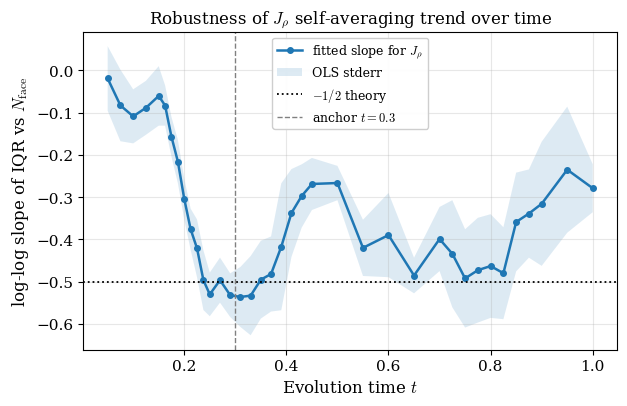

Saved: slope_vs_time_robustness_Jrho.png


In [21]:
# ============================================================
# J_rho slope-vs-time robustness
# ============================================================

rho_slope_rows = []

common_t_sets = []
for N in N_LIST_RHO:
    common_t_sets.append(set(np.round(dfs[N]["t"].unique(), 10)))

common_t = sorted(set.intersection(*common_t_sets))

for t0 in common_t:
    iqrs_t = []

    for N in N_LIST_RHO:
        dfN = dfs[N]
        sub = dfN[np.isclose(dfN["t"], t0)].copy()

        if sub.empty:
            iqrs_t.append(np.nan)
            continue

        vals = sub[RHO_COL].dropna().values
        iqrs_t.append(width_iqr(vals))

    iqrs_t = np.asarray(iqrs_t, dtype=float)

    if np.any(~np.isfinite(iqrs_t)) or np.any(iqrs_t <= 0):
        continue

    fit_t = stats.linregress(np.log(rho_n_faces), np.log(iqrs_t))

    rho_slope_rows.append({
        "t": float(t0),
        "slope": float(fit_t.slope),
        "beta_positive": float(-fit_t.slope),
        "stderr": float(fit_t.stderr),
        "R2": float(fit_t.rvalue ** 2),
        "pvalue": float(fit_t.pvalue),
    })

rho_slope_time_df = pd.DataFrame(rho_slope_rows)

display(rho_slope_time_df.head())
display(rho_slope_time_df.tail())

print("=" * 60)
print("J_rho slope-vs-time robustness near representative times")
print("=" * 60)

for t_query in [0.15, 0.30, 0.50, 0.70, 0.90]:
    idx = np.argmin(np.abs(rho_slope_time_df["t"].values - t_query))
    row = rho_slope_time_df.iloc[idx]
    print(
        f"t={row['t']:.3f}: "
        f"slope={row['slope']:+.3f}, "
        f"beta={row['beta_positive']:.3f}, "
        f"R2={row['R2']:.3f}"
    )

plt.figure(figsize=(6.4, 4.2))

plt.plot(
    rho_slope_time_df["t"],
    rho_slope_time_df["slope"],
    "-o",
    markersize=4,
    linewidth=1.8,
    label=r"fitted slope for $J_\rho$",
)

plt.fill_between(
    rho_slope_time_df["t"],
    rho_slope_time_df["slope"] - rho_slope_time_df["stderr"],
    rho_slope_time_df["slope"] + rho_slope_time_df["stderr"],
    alpha=0.15,
    label="OLS stderr",
)

plt.axhline(-0.5, color="black", linestyle=":", linewidth=1.3,
            label=r"$-1/2$ theory")

plt.axvline(T_RHO_ANCHOR, color="gray", linestyle="--", linewidth=1.0,
            label=rf"anchor $t={T_RHO_ANCHOR}$")

plt.xlabel("Evolution time $t$")
plt.ylabel(r"log-log slope of IQR vs $N_{\rm face}$")
plt.title(r"Robustness of $J_\rho$ self-averaging trend over time")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9, framealpha=0.95)
plt.tight_layout()

plt.savefig("slope_vs_time_robustness_Jrho.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: slope_vs_time_robustness_Jrho.png")

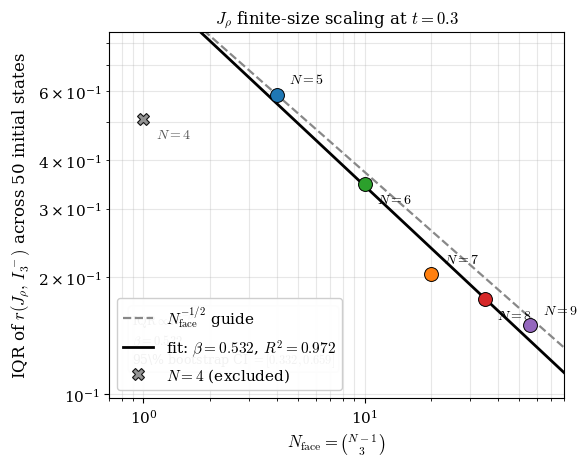

In [22]:
# ============================================================
# J_rho money plot
# ============================================================

rho_iqr_N4 = rho_scaling_df.loc[rho_scaling_df["N"] == 4, "iqr"].iloc[0]

colors_N = {
    4: '#888888',
    5: '#1f77b4',
    6: '#2ca02c',
    7: '#ff7f0e',
    8: '#d62728',
    9: '#9467bd'
}

rho_beta_fit = -rho_fit.slope
rho_beta_ci_low = min(-rho_boot_slope_ci95[0], -rho_boot_slope_ci95[1])
rho_beta_ci_high = max(-rho_boot_slope_ci95[0], -rho_boot_slope_ci95[1])

fig, ax = plt.subplots(figsize=(6.0, 4.8))

x_ref = np.logspace(np.log10(0.7), np.log10(80), 200)

# theory guide anchored at first fitted point
y_theory = rho_iqrs[0] * (x_ref / rho_n_faces[0]) ** BETA_THEORY
y_fit = np.exp(rho_fit.intercept) * x_ref ** rho_fit.slope

ax.plot(
    x_ref, y_theory, '--',
    color='#888888', lw=1.6,
    label=r'$N_{\rm face}^{-1/2}$ guide'
)

ax.plot(
    x_ref, y_fit, '-',
    color='black', lw=2.0,
    label=fr'fit: $\beta = {rho_beta_fit:.3f}$, $R^2 = {rho_fit.rvalue**2:.3f}$'
)

offsets = {
    5: (9, 8),
    6: (9, -14),
    7: (9, 8),
    8: (9, -14),
    9: (9, 8),
}

for N, nf, iqr in zip(N_LIST_RHO, rho_n_faces, rho_iqrs):
    ax.loglog(
        nf, iqr, 'o',
        ms=10, color=colors_N[N],
        mec='black', mew=0.7, zorder=5
    )
    dx, dy = offsets.get(N, (9, 8))
    ax.annotate(
        f'$N={N}$',
        (nf, iqr),
        textcoords='offset points',
        xytext=(dx, dy),
        fontsize=10
    )

# N=4 excluded marker
ax.loglog(
    1, rho_iqr_N4, 'X',
    ms=9, color=colors_N[4],
    mec='black', mew=0.8,
    zorder=5, alpha=0.9,
    label='$N=4$ (excluded)'
)
ax.annotate(
    '$N=4$',
    (1, rho_iqr_N4),
    textcoords='offset points',
    xytext=(9, -14),
    fontsize=10,
    color='#555555'
)

textstr = (
    rf'$\mathrm{{IQR}}\propto N_{{\rm face}}^{{-\beta}}$' '\n'
    rf'$\beta={rho_beta_fit:.3f}$' '\n'
    rf'95\% bootstrap CI $=[{rho_beta_ci_low:.3f},{rho_beta_ci_high:.3f}]$'
)

ax.text(
    0.05, 0.08, textstr,
    transform=ax.transAxes,
    fontsize=9,
    va='bottom',
    ha='left',
    bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.92, boxstyle='round,pad=0.3')
)

ax.set_xlabel(r'$N_{\rm face} = \binom{N-1}{3}$')
ax.set_ylabel(r'IQR of $r(J_{\rho},\, I_3^-)$ across 50 initial states')

ax.set_title(
    fr'$J_\rho$ finite-size scaling at $t = {T_RHO_ANCHOR}$'
)

ax.legend(loc='lower left', frameon=True, framealpha=0.95)
ax.set_xlim(0.7, 80)

all_y = np.r_[rho_iqrs, rho_iqr_N4]
ax.set_ylim(max(0.02, all_y.min() * 0.65), all_y.max() * 1.45)

ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('tier_S_money_plot_Jrho.png', dpi=300, bbox_inches='tight')
plt.savefig('tier_S_money_plot_Jrho.pdf', bbox_inches='tight')
plt.show()

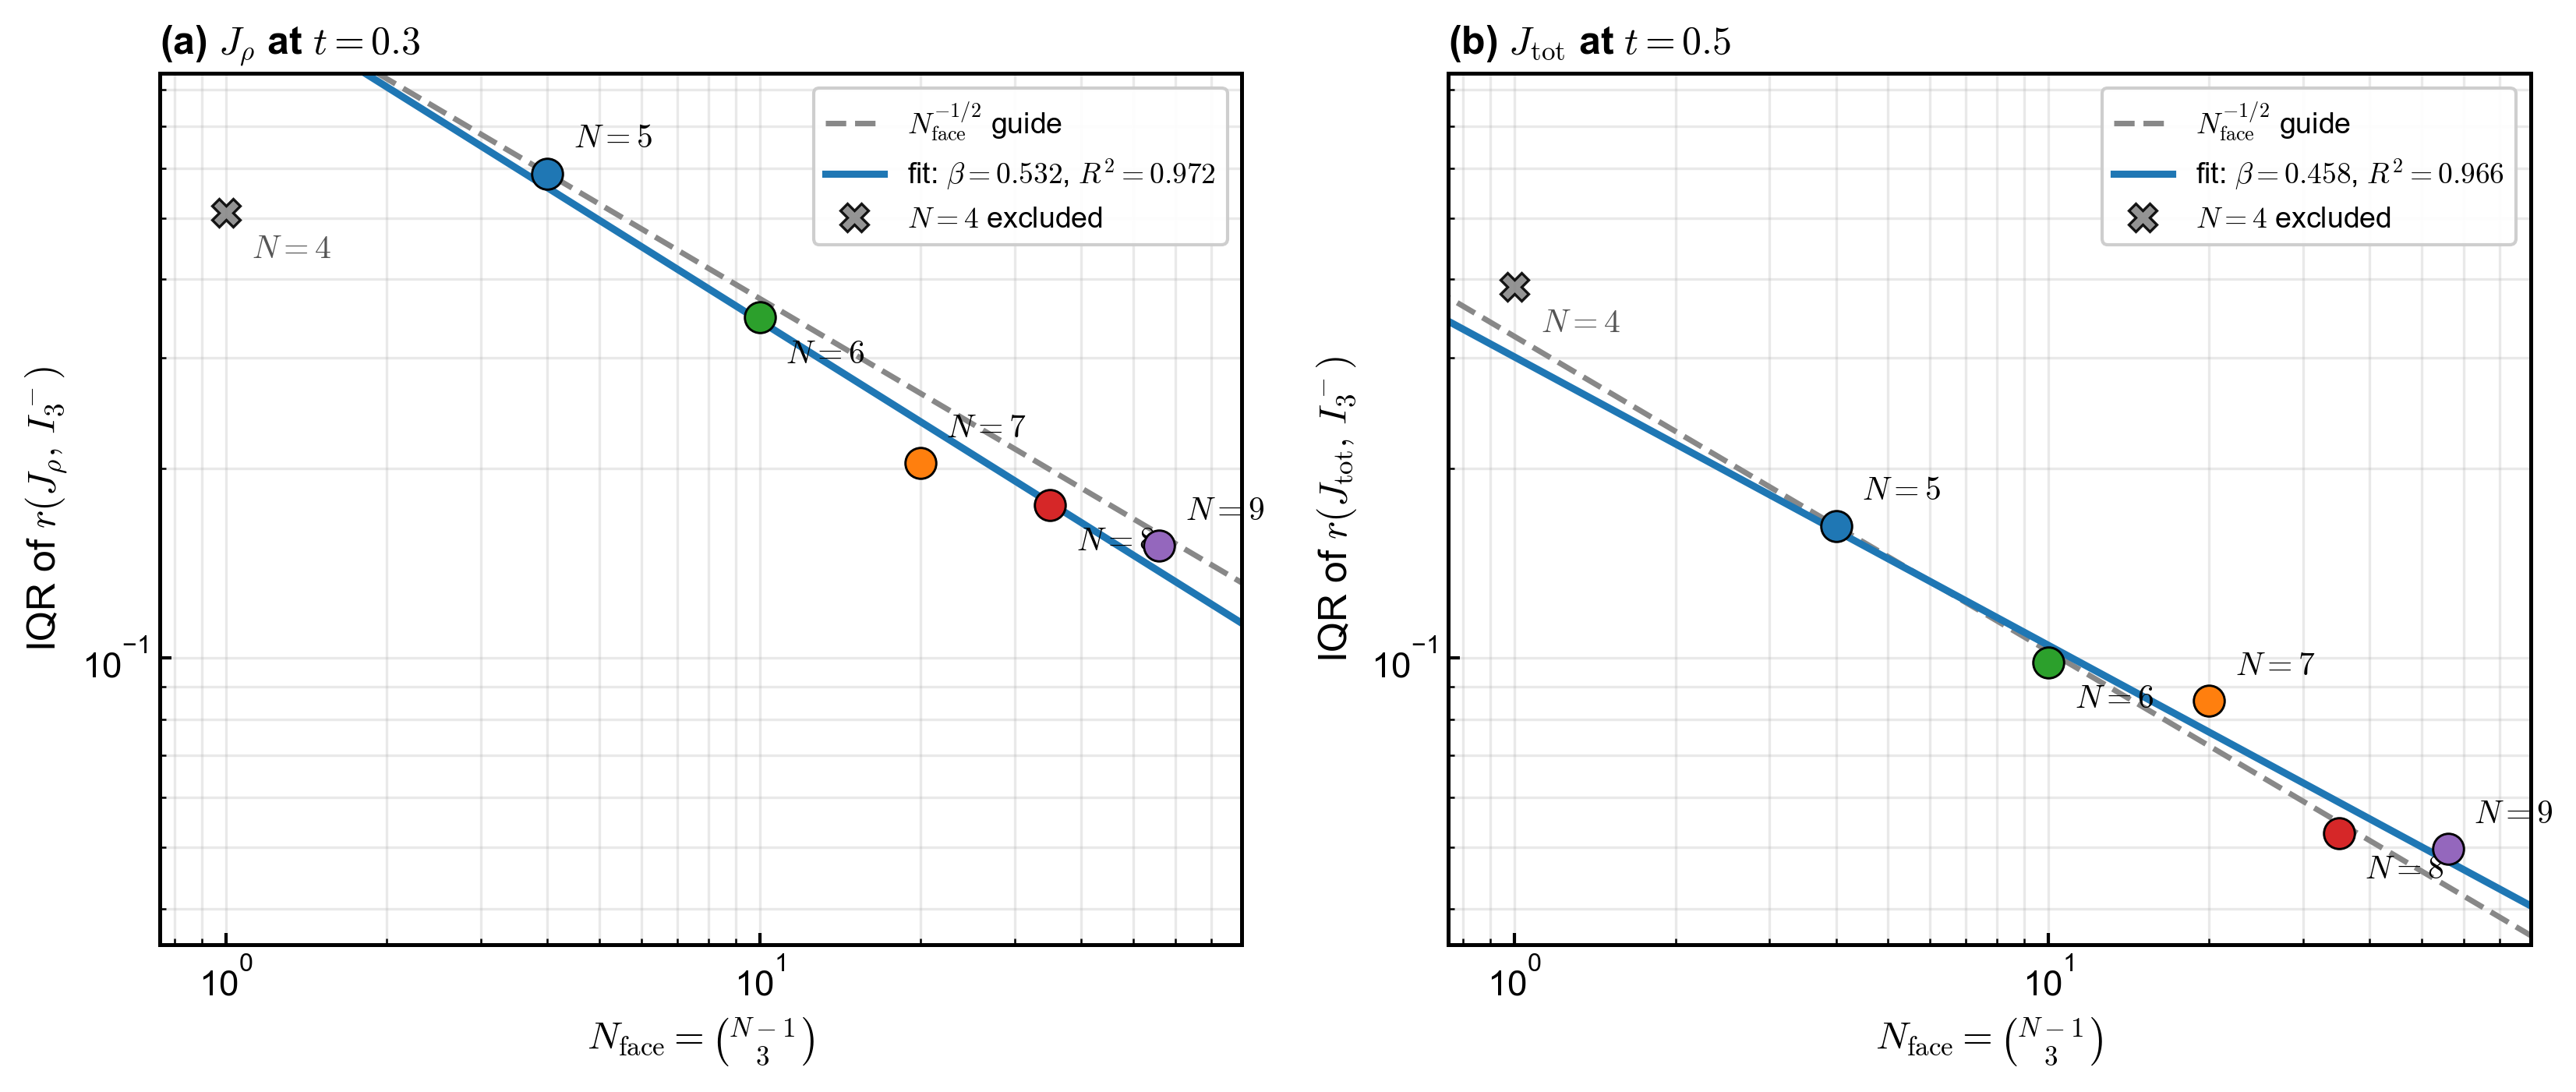

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Basic style
# ------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'figure.dpi': 300,
})

# ------------------------------------------------------------
# Common settings
# ------------------------------------------------------------
colors_N = {
    4: '#888888',
    5: '#1f77b4',
    6: '#2ca02c',
    7: '#ff7f0e',
    8: '#d62728',
    9: '#9467bd',
}

offsets = {
    5: (8, 8),
    6: (8, -14),
    7: (8, 8),
    8: (8, -14),
    9: (8, 8),
}

x_ref = np.logspace(np.log10(0.7), np.log10(80), 300)

# ------------------------------------------------------------
# N=4 excluded references
# ------------------------------------------------------------
df4 = pd.read_csv(f'{INPUT_DIR}/all_summaries_N4.csv')
_, iqr_N4_tot = iqr_at_t(df4, T_ANCHOR)

if "rho_scaling_df" in globals() and (rho_scaling_df["N"] == 4).any():
    rho_iqr_N4 = rho_scaling_df.loc[rho_scaling_df["N"] == 4, "iqr"].iloc[0]
else:
    def iqr_at_t_for_col(df, t_anchor, col):
        t_unique = np.array(sorted(df["t"].unique()), dtype=float)
        t_actual = t_unique[np.argmin(np.abs(t_unique - t_anchor))]
        sub = df[np.isclose(df["t"], t_actual)].copy()
        vals = sub[col].dropna().values
        iqr_val = np.percentile(vals, 75) - np.percentile(vals, 25)
        return t_actual, iqr_val

    _, rho_iqr_N4 = iqr_at_t_for_col(df4, T_RHO_ANCHOR, "corr_J_rho")

# ------------------------------------------------------------
# Positive exponent convention:
# IQR ~ N_face^{-beta}
# ------------------------------------------------------------
beta_tot = -fit.slope
beta_rho = -rho_fit.slope

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------
def draw_scaling_panel(
    ax,
    N_fit_list,
    n_faces_fit,
    iqrs_fit,
    fit_obj,
    beta_text,
    iqr_N4,
    panel_label,
    panel_title,
    y_label,
    legend_loc='upper right',
):
    # Theory guide: slope only, anchored at N=5 point.
    # This avoids implying an independently predicted prefactor.
    y_theory = iqrs_fit[0] * (x_ref / n_faces_fit[0]) ** BETA_THEORY

    # Empirical log-log fit.
    y_fit = np.exp(fit_obj.intercept) * x_ref ** fit_obj.slope

    ax.plot(
        x_ref, y_theory, '--',
        color='#888888', lw=1.7,
        label=r'$N_{\rm face}^{-1/2}$ guide'
    )

    ax.plot(
        x_ref, y_fit, '-',
        color='#1f77b4', lw=2.2,
        label=fr'fit: $\beta={beta_text:.3f}$, $R^2={fit_obj.rvalue**2:.3f}$'
    )

    # Fitted points: N=5--9
    for N, nf, iqr in zip(N_fit_list, n_faces_fit, iqrs_fit):
        ax.loglog(
            nf, iqr, 'o',
            ms=9.5,
            color=colors_N[N],
            mec='black',
            mew=0.7,
            zorder=5
        )
        dx, dy = offsets.get(N, (8, 8))
        ax.annotate(
            fr'$N={N}$',
            (nf, iqr),
            textcoords='offset points',
            xytext=(dx, dy),
            fontsize=10
        )

    # N=4 excluded reference
    ax.loglog(
        1, iqr_N4, 'X',
        ms=8.5,
        color=colors_N[4],
        mec='black',
        mew=0.8,
        alpha=0.9,
        zorder=5,
        label=r'$N=4$ excluded'
    )

    ax.annotate(
        r'$N=4$',
        (1, iqr_N4),
        textcoords='offset points',
        xytext=(8, -14),
        fontsize=10,
        color='#555555'
    )

    ax.set_xlabel(r'$N_{\rm face}=\binom{N-1}{3}$')
    ax.set_ylabel(y_label)
    ax.set_title(panel_label + ' ' + panel_title,
                 loc='left', fontweight='bold', fontsize=12)

    ax.set_xlim(0.75, 80)
    ax.grid(alpha=0.28, which='both')
    ax.legend(loc=legend_loc, frameon=True, framealpha=0.95, fontsize=9)


# ------------------------------------------------------------
# Draw two-panel figure
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.2, 4.8))

# (a) J_rho
draw_scaling_panel(
    ax=ax1,
    N_fit_list=[5, 6, 7, 8, 9],
    n_faces_fit=rho_n_faces,
    iqrs_fit=rho_iqrs,
    fit_obj=rho_fit,
    beta_text=beta_rho,
    iqr_N4=rho_iqr_N4,
    panel_label='(a)',
    panel_title=(r'$J_{\rho}$ at ' + fr'$t={T_RHO_ANCHOR}$'),
    y_label=r'IQR of $r(J_{\rho},\,I_3^-)$',
    legend_loc='upper right',
)

# (b) J_tot
draw_scaling_panel(
    ax=ax2,
    N_fit_list=N_LIST,
    n_faces_fit=n_faces,
    iqrs_fit=iqrs,
    fit_obj=fit,
    beta_text=beta_tot,
    iqr_N4=iqr_N4_tot,
    panel_label='(b)',
    panel_title=(r'$J_{\mathrm{tot}}$ at ' + fr'$t={T_ANCHOR}$'),
    y_label=r'IQR of $r(J_{\mathrm{tot}},\,I_3^-)$',
    legend_loc='upper right',
)

# ------------------------------------------------------------
# Shared y-axis range
# ------------------------------------------------------------
shared_ylim = (0.035, 0.85)
for ax in (ax1, ax2):
    ax.set_ylim(shared_ylim)

fig.tight_layout()

plt.savefig('finite_size_scaling_dual_panel_clean_sharedY.png',
            dpi=300, bbox_inches='tight')
plt.savefig('finite_size_scaling_dual_panel_clean_sharedY.pdf',
            bbox_inches='tight')
plt.show()

In [32]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Configure folders
# ============================================================

folders_by_N = {
    4: [
        "results_N4_broad_xyz_n50_g12_seed1000",
    ],
    5: [
        "results_N5_broad_xyz_n50_g12_seed1000",
    ],
    6: [
        "results_N6_broad_xyz_n50_g12_seed1000",
    ],
    7: [
        "results_N7_broad_xyz_n50_g12_seed1000",
    ],
    8: [
        "results_N8_broad_xyz_n50_g12_seed1000",
    ],
    9: [
        "results_N9_broad_xyz_n50_g12_seed1000",
    ],
}


def load_summary_folder(folder):
    """
    Load one output folder.
    Prefer all_summaries.csv if available; otherwise merge per-state CSVs.
    """
    all_summary_path = os.path.join(folder, "all_summaries.csv")

    if os.path.exists(all_summary_path):
        return pd.read_csv(all_summary_path)

    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    files = [f for f in files if not os.path.basename(f).startswith("all_summaries")]

    if not files:
        raise FileNotFoundError(f"No CSV files found in {folder}")

    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


# ============================================================
# 2. Load all available N
# ============================================================

dfs = []

for N, folders in folders_by_N.items():
    loaded_any = False

    for folder in folders:
        if os.path.exists(folder):
            dfN = load_summary_folder(folder)
            dfN["N_loaded_from_config"] = N
            dfN["source_folder"] = folder
            dfs.append(dfN)

            print(
                f"Loaded N={N} from {folder}: "
                f"shape={dfN.shape}, states={dfN['state_seed'].nunique()}"
            )
            loaded_any = True

    if not loaded_any:
        print(f"No folder found for N={N}. Skipped.")

df_all = pd.concat(dfs, ignore_index=True)

# Remove exact duplicate rows if the same result is loaded twice.
dedup_cols = ["N", "state_seed", "t", "family", "effective_base_seed"]
dedup_cols = [c for c in dedup_cols if c in df_all.columns]
df_all = df_all.drop_duplicates(subset=dedup_cols).reset_index(drop=True)

print("\nCombined shape:", df_all.shape)
print("\nState counts by N:")
print(df_all.groupby("N")["state_seed"].nunique())

print("\nRows by N:")
print(df_all.groupby("N").size())

display(df_all.head())

Loaded N=4 from results_N4_broad_xyz_n50_g12_seed1000: shape=(1900, 23), states=50
Loaded N=5 from results_N5_broad_xyz_n50_g12_seed1000: shape=(1900, 22), states=50
Loaded N=6 from results_N6_broad_xyz_n50_g12_seed1000: shape=(1900, 22), states=50
Loaded N=7 from results_N7_broad_xyz_n50_g12_seed1000: shape=(1900, 22), states=50
Loaded N=8 from results_N8_broad_xyz_n50_g12_seed1000: shape=(1900, 23), states=50
Loaded N=9 from results_N9_broad_xyz_n50_g12_seed1000: shape=(1900, 22), states=50

Combined shape: (11400, 23)

State counts by N:
N
4    50
5    50
6    50
7    50
8    50
9    50
Name: state_seed, dtype: int64

Rows by N:
N
4    1900
5    1900
6    1900
7    1900
8    1900
9    1900
dtype: int64


,Unnamed: 0,t,N,n_points,base_seed_requested,effective_base_seed,state_seed,family,family_min_jtot,health_check,...,corr_P_pair,corr_N_pair,corr_N_env,target_max,target_mean,J_tot_min_grid,J_tot_mean_grid,state_idx,N_loaded_from_config,source_folder
0,0.0,0.050,4,144,1,1,1000,broad_xyz,22.359645,False,...,0.468157,0.491682,0.869652,0.000739,0.000250,1.985574e-15,17.592496,0,4,results_N4_broad_xyz_n50_g12_seed1000
1,1.0,0.075,4,144,1,1,1000,broad_xyz,22.359645,False,...,0.476820,0.515662,0.848593,0.001715,0.000600,1.985574e-15,17.592496,0,4,results_N4_broad_xyz_n50_g12_seed1000
2,2.0,0.100,4,144,1,1,1000,broad_xyz,22.359645,False,...,0.479257,0.539186,0.826083,0.003187,0.001169,1.985574e-15,17.592496,0,4,results_N4_broad_xyz_n50_g12_seed1000
3,3.0,0.125,4,144,1,1,1000,broad_xyz,22.359645,False,...,0.483590,0.566887,0.798486,0.005260,0.002020,1.985574e-15,17.592496,0,4,results_N4_broad_xyz_n50_g12_seed1000
4,4.0,0.150,4,144,1,1,1000,broad_xyz,22.359645,False,...,0.491821,0.596304,0.765323,0.008060,0.003223,1.985574e-15,17.592496,0,4,results_N4_broad_xyz_n50_g12_seed1000


In [33]:
# ============================================================
# 3. Page-theory helper
# ============================================================

def harmonic_number(n):
    return sum(1.0 / k for k in range(1, n + 1))


def page_entropy_bits(k, N):
    """
    Page entropy in bits for a k-qubit subsystem of an N-qubit Haar-random pure state.
    """
    dA = 2 ** k
    dB = 2 ** (N - k)

    m = min(dA, dB)
    n = max(dA, dB)

    # Page formula in nats:
    # E[S] = H_{mn} - H_n - (m - 1)/(2n), for m <= n.
    S_nats = harmonic_number(m * n) - harmonic_number(n) - (m - 1) / (2 * n)
    return S_nats / math.log(2)


def page_I3_minus_face(N):
    """
    Page estimate for I3^- of a 3-qubit face in an N-qubit pure state.
    I3 = 3S1 - 3S2 + S3.
    """
    S1 = page_entropy_bits(1, N)
    S2 = page_entropy_bits(2, N)
    S3 = page_entropy_bits(3, N)

    I3 = 3 * S1 - 3 * S2 + S3
    return max(0.0, -I3), I3, S1, S2, S3


def n_faces_for_N(N):
    # Internal core = K_{N-1}; triangular faces = C(N-1, 3)
    return math.comb(N - 1, 3)


# ============================================================
# 4. Page table
# ============================================================

page_rows = []

for N in sorted(df_all["N"].unique()):
    I3m_page, I3_page, S1, S2, S3 = page_I3_minus_face(int(N))
    page_rows.append({
        "N": int(N),
        "N_faces": n_faces_for_N(int(N)),
        "S1_Page": S1,
        "S2_Page": S2,
        "S3_Page": S3,
        "I3_Page": I3_page,
        "I3_minus_Page": I3m_page,
    })

page_df = pd.DataFrame(page_rows)
display(page_df)


# ============================================================
# 5. Time-resolved ensemble statistics
# ============================================================

stats_t = (
    df_all.groupby(["N", "t"])
    .agg(
        n_states=("state_seed", "nunique"),

        corr_Jrho_med=("corr_J_rho", "median"),
        corr_Jrho_q25=("corr_J_rho", lambda x: x.quantile(0.25)),
        corr_Jrho_q75=("corr_J_rho", lambda x: x.quantile(0.75)),

        corr_Jtot_med=("corr_J_tot", "median"),
        corr_Jtot_q25=("corr_J_tot", lambda x: x.quantile(0.25)),
        corr_Jtot_q75=("corr_J_tot", lambda x: x.quantile(0.75)),

        target_mean_med=("target_mean", "median"),
        target_mean_q25=("target_mean", lambda x: x.quantile(0.25)),
        target_mean_q75=("target_mean", lambda x: x.quantile(0.25)),

        target_max_med=("target_max", "median"),
        target_max_q25=("target_max", lambda x: x.quantile(0.25)),
        target_max_q75=("target_max", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

stats_t = stats_t.merge(page_df[["N", "N_faces", "I3_minus_Page"]], on="N", how="left")

stats_t["corr_Jrho_iqr"] = stats_t["corr_Jrho_q75"] - stats_t["corr_Jrho_q25"]
stats_t["corr_Jtot_iqr"] = stats_t["corr_Jtot_q75"] - stats_t["corr_Jtot_q25"]

stats_t["Q_mean_med"] = stats_t["target_mean_med"] / stats_t["I3_minus_Page"]
stats_t["Q_max_med"]  = stats_t["target_max_med"]  / stats_t["I3_minus_Page"]

display(stats_t.head())

,N,N_faces,S1_Page,S2_Page,S3_Page,I3_Page,I3_minus_Page
0,4,1,0.866153,1.330736,0.866153,-0.527593,0.527593
1,5,4,0.932726,1.663627,1.663627,-0.529076,0.529076
2,6,10,0.966275,1.831374,2.291770,-0.303528,0.303528
3,7,20,0.983115,1.915577,2.645424,-0.151961,0.151961
4,8,35,0.991552,1.957761,2.822596,-0.076030,0.076030
5,9,56,0.995775,1.978874,2.911269,-0.038027,0.038027


,N,t,n_states,corr_Jrho_med,corr_Jrho_q25,corr_Jrho_q75,corr_Jtot_med,corr_Jtot_q25,corr_Jtot_q75,target_mean_med,...,target_mean_q75,target_max_med,target_max_q25,target_max_q75,N_faces,I3_minus_Page,corr_Jrho_iqr,corr_Jtot_iqr,Q_mean_med,Q_max_med
0,4,0.050,50,0.283455,-0.005786,0.715133,0.240585,0.011843,0.406529,0.000108,...,0.000064,0.000474,0.000379,0.000745,1,0.527593,0.720918,0.394686,0.000205,0.000898
1,4,0.075,50,0.329584,-0.114015,0.656794,0.212351,0.037021,0.409120,0.000254,...,0.000155,0.001105,0.000885,0.001710,1,0.527593,0.770809,0.372098,0.000481,0.002094
2,4,0.100,50,0.325828,-0.155316,0.633360,0.188963,0.046607,0.419099,0.000480,...,0.000315,0.002092,0.001645,0.003164,1,0.527593,0.788676,0.372491,0.000910,0.003965
3,4,0.125,50,0.304806,-0.181762,0.589970,0.191534,0.034344,0.420325,0.000837,...,0.000556,0.003558,0.002764,0.005170,1,0.527593,0.771732,0.385981,0.001587,0.006744
4,4,0.150,50,0.277431,-0.213431,0.568896,0.196961,0.027058,0.408845,0.001335,...,0.000854,0.005508,0.004417,0.007925,1,0.527593,0.782327,0.381786,0.002530,0.010440


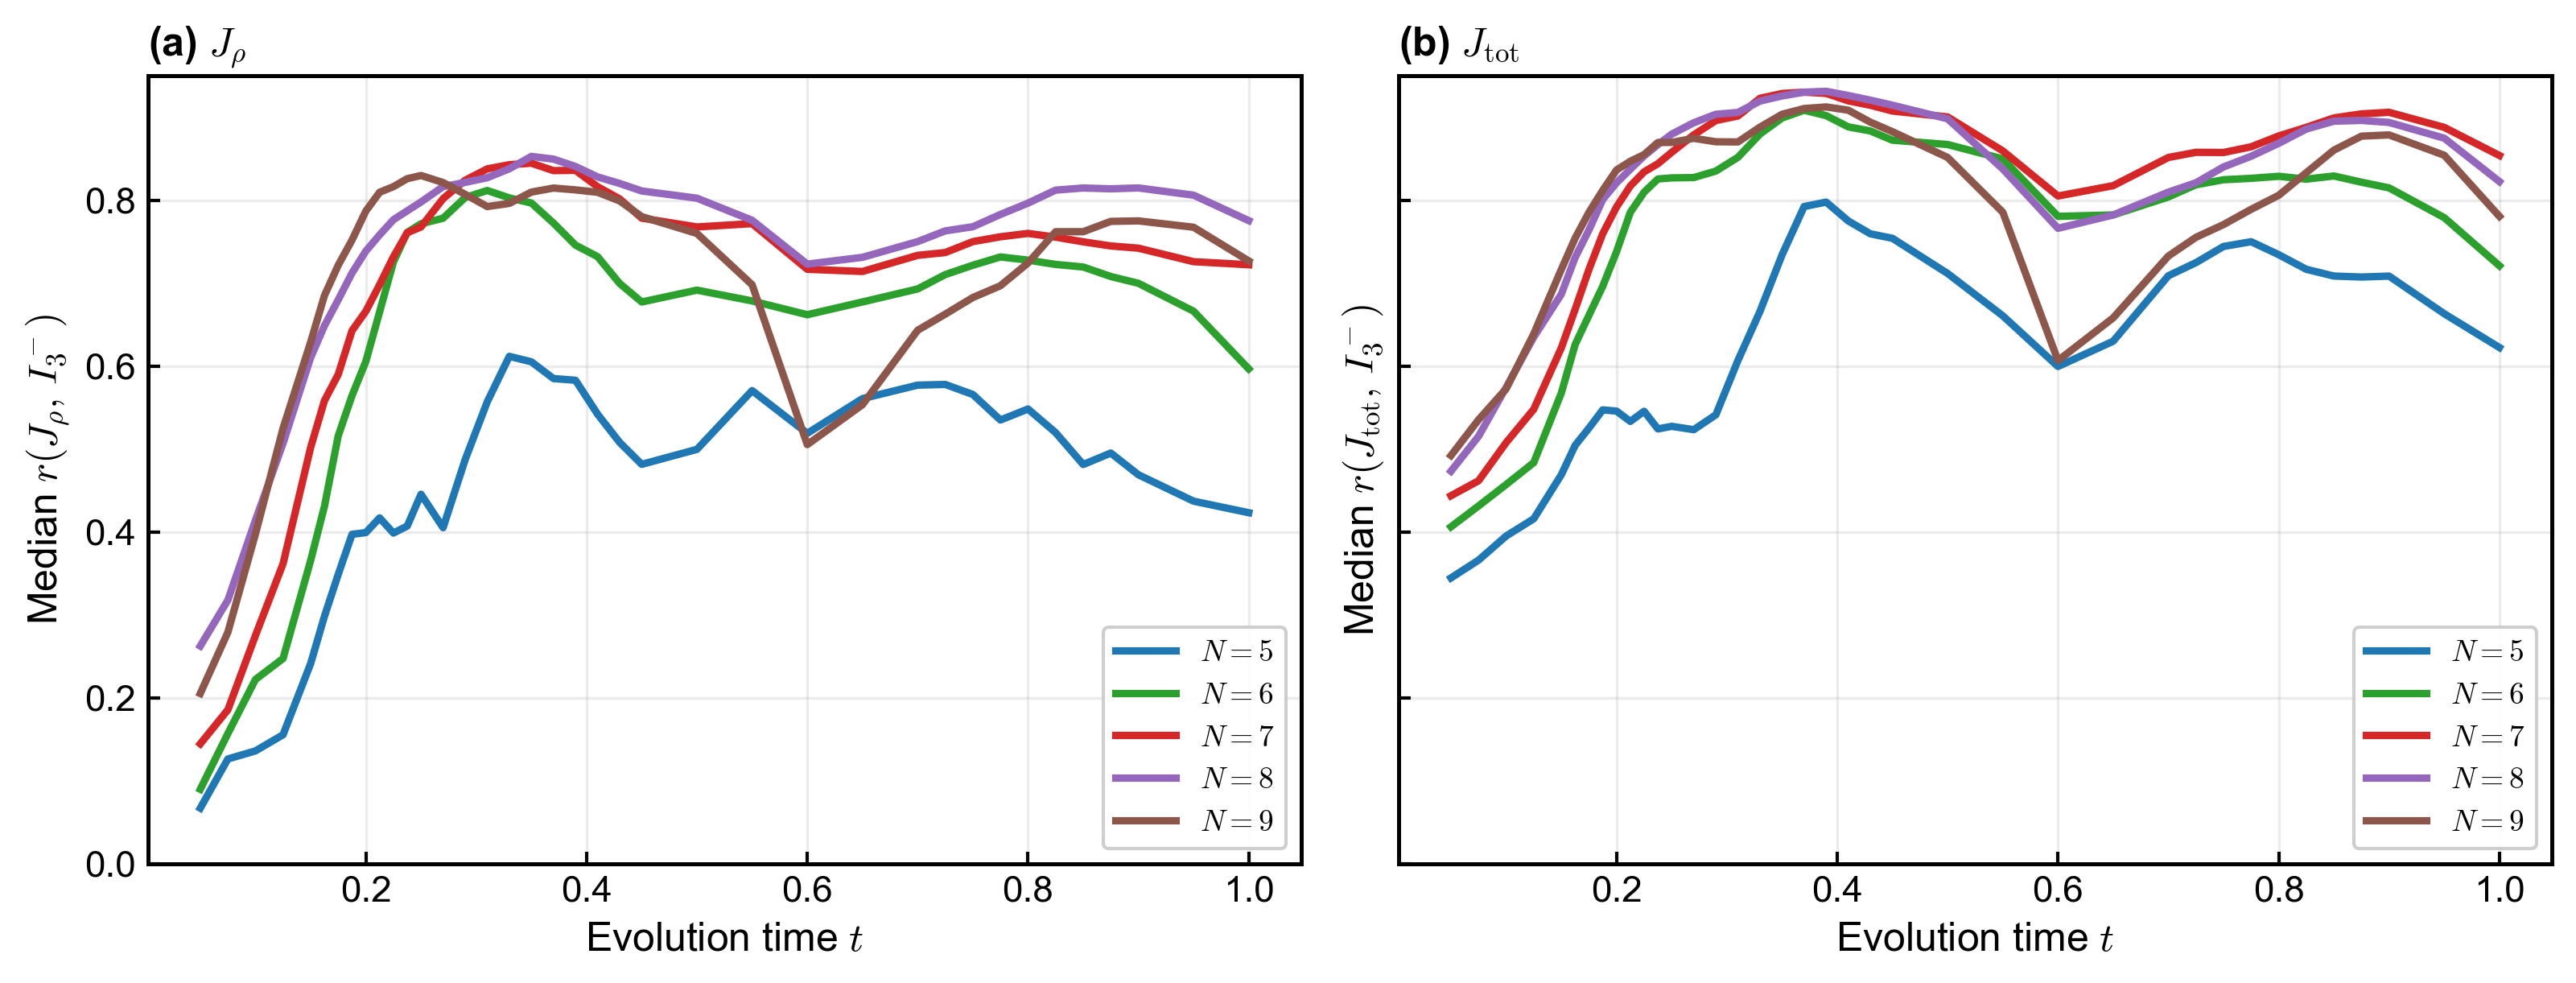

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# If needed: build dfs_by_N
# ------------------------------------------------------------
if "dfs_by_N" not in globals():
    if "df_all" in globals():
        dfs_by_N = {int(N): sub.copy() for N, sub in df_all.groupby("N")}
    elif isinstance(dfs, dict):
        dfs_by_N = dfs
    else:
        raise RuntimeError("Need dfs_by_N or df_all.")

# ------------------------------------------------------------
# style
# ------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'figure.dpi': 300,
    'mathtext.fontset': 'cm',
})

# ------------------------------------------------------------
# settings
# ------------------------------------------------------------
N_list = [5, 6, 7, 8, 9]

colors = {
    5: '#1f77b4',   # blue
    6: '#2ca02c',   # green
    7: '#d62728',   # red
    8: '#9467bd',   # purple
    9: '#8c564b',   # brown
}

# ------------------------------------------------------------
# build median trajectories only
# ------------------------------------------------------------
rows = []

for N in N_list:
    if N not in dfs_by_N:
        continue

    dfN = dfs_by_N[N].copy()

    for t, sub in dfN.groupby("t"):
        rows.append({
            "N": N,
            "t": float(t),
            "Jrho_med": np.median(sub["corr_J_rho"].dropna().values),
            "Jtot_med": np.median(sub["corr_J_tot"].dropna().values),
        })

traj_df = pd.DataFrame(rows).sort_values(["N", "t"])

# ------------------------------------------------------------
# plotting helper
# ------------------------------------------------------------
def plot_channel(ax, metric_col, ylabel, panel_label, panel_title):
    for N in N_list:
        if N not in traj_df["N"].unique():
            continue

        sub = traj_df[traj_df["N"] == N].sort_values("t")

        ax.plot(
            sub["t"], sub[metric_col],
            color=colors[N],
            linewidth=2.2,
            label=fr'$N={N}$'
        )

    ax.axhline(0, color='black', linewidth=0.8, linestyle=':', zorder=1)
    ax.set_xlabel(r'Evolution time $t$')
    ax.set_ylabel(ylabel)
    ax.set_title(panel_label + ' ' + panel_title, loc='left',
                 fontweight='bold', fontsize=12)
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=9)


# ------------------------------------------------------------
# draw figure
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.8, 4.2), sharex=True, sharey=True)

plot_channel(
    ax1,
    metric_col="Jrho_med",
    ylabel=r'Median $r(J_{\rho},\,I_3^-)$',
    panel_label='(a)',
    panel_title=r'$J_{\rho}$'
)

plot_channel(
    ax2,
    metric_col="Jtot_med",
    ylabel=r'Median $r(J_{\mathrm{tot}},\,I_3^-)$',
    panel_label='(b)',
    panel_title=r'$J_{\mathrm{tot}}$'
)

# shared range for clean comparison
ax1.set_ylim(0.0, 0.95)
ax2.set_ylim(0.0, 0.95)

fig.tight_layout()

plt.savefig('sm_crossN_correlation_trajectories_median_only.png', dpi=300, bbox_inches='tight')
plt.savefig('sm_crossN_correlation_trajectories_median_only.pdf', bbox_inches='tight')
plt.show()

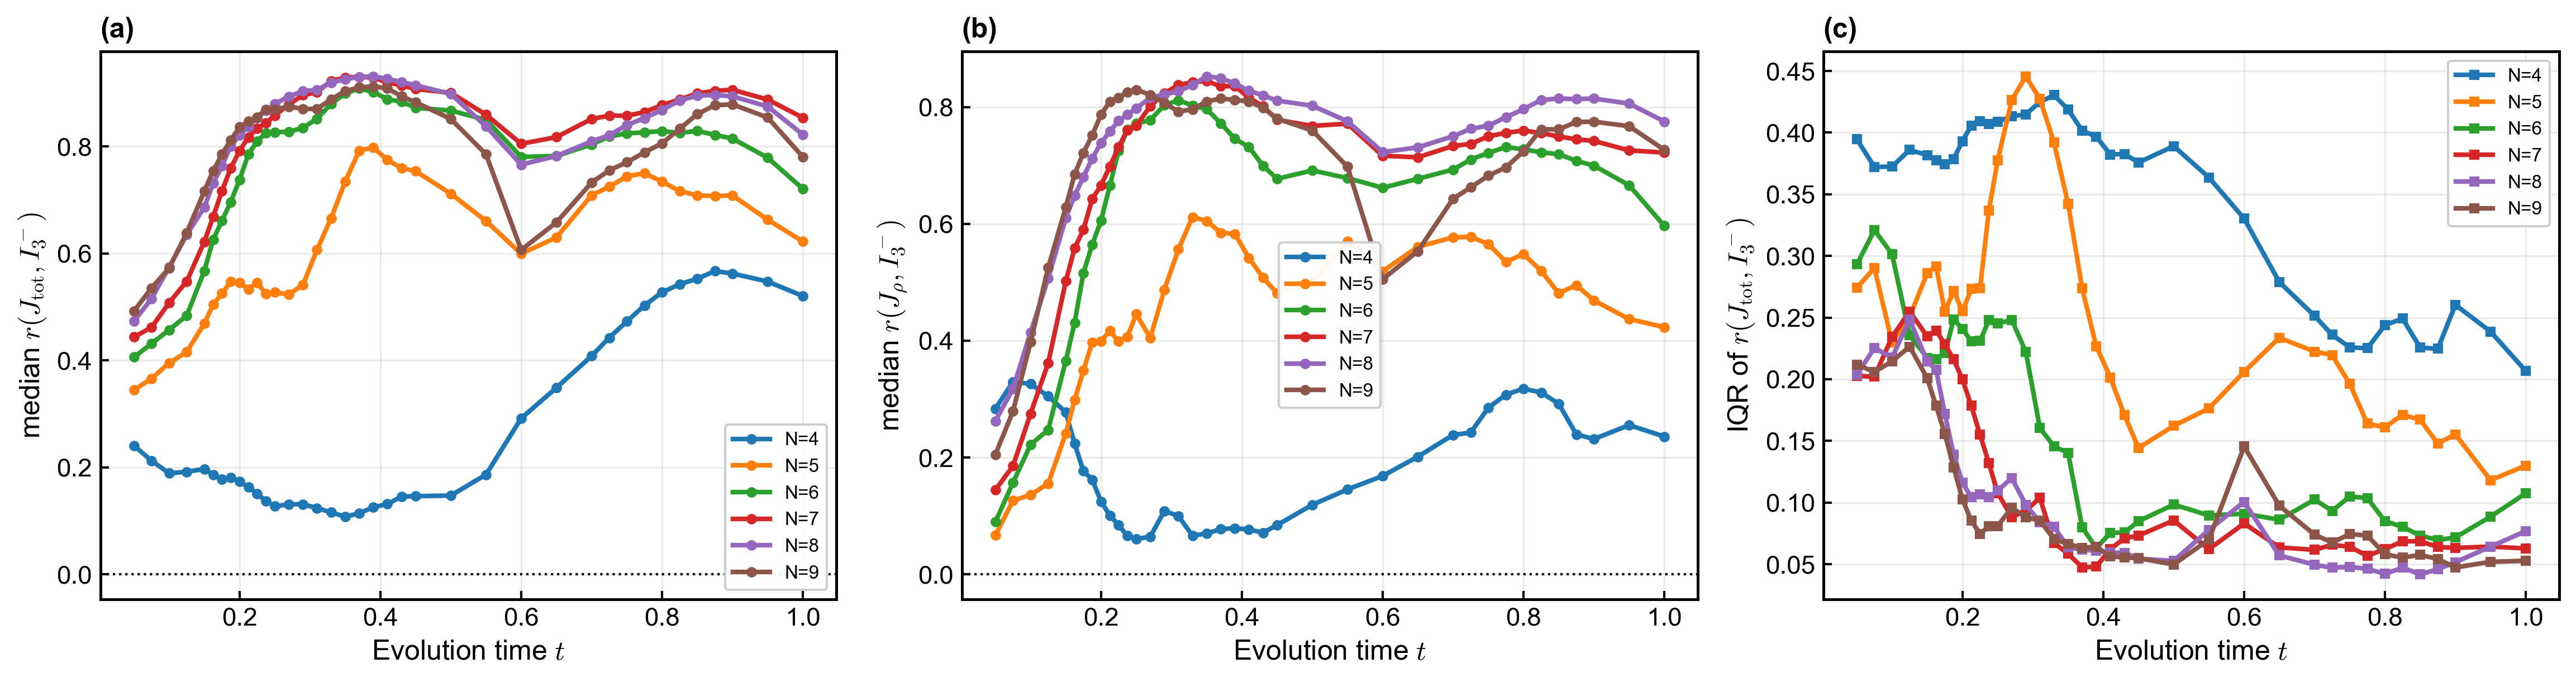

Saved: finite_size_time_trends_correlations.png


In [34]:
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 300,
})

Ns = sorted(stats_t["N"].unique())

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2), sharex=True)

ax1, ax2, ax3 = axes

for N in Ns:
    sub = stats_t[stats_t["N"] == N].sort_values("t")
    label = f"N={int(N)}"

    ax1.plot(
        sub["t"], sub["corr_Jtot_med"],
        "-o", markersize=3.5, linewidth=2.0,
        label=label,
    )

    ax2.plot(
        sub["t"], sub["corr_Jrho_med"],
        "-o", markersize=3.5, linewidth=2.0,
        label=label,
    )

    ax3.plot(
        sub["t"], sub["corr_Jtot_iqr"],
        "-s", markersize=3.5, linewidth=2.0,
        label=label,
    )

ax1.axhline(0, color="black", linestyle=":", linewidth=1.0)
ax2.axhline(0, color="black", linestyle=":", linewidth=1.0)

ax1.set_title("(a)", loc="left", fontweight="bold")
ax1.set_ylabel(r"median $r(J_{\rm tot}, I_3^-)$")
ax1.set_xlabel("Evolution time $t$")
ax1.grid(True, alpha=0.25)
ax1.legend(fontsize=8, framealpha=0.95)

ax2.set_title("(b)", loc="left", fontweight="bold")
ax2.set_ylabel(r"median $r(J_{\rho}, I_3^-)$")
ax2.set_xlabel("Evolution time $t$")
ax2.grid(True, alpha=0.25)
ax2.legend(fontsize=8, framealpha=0.95)

ax3.set_title("(c)", loc="left", fontweight="bold")
ax3.set_ylabel(r"IQR of $r(J_{\rm tot}, I_3^-)$")
ax3.set_xlabel("Evolution time $t$")
ax3.grid(True, alpha=0.25)
ax3.legend(fontsize=8, framealpha=0.95)

fig.tight_layout()

save_path = "finite_size_time_trends_correlations.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

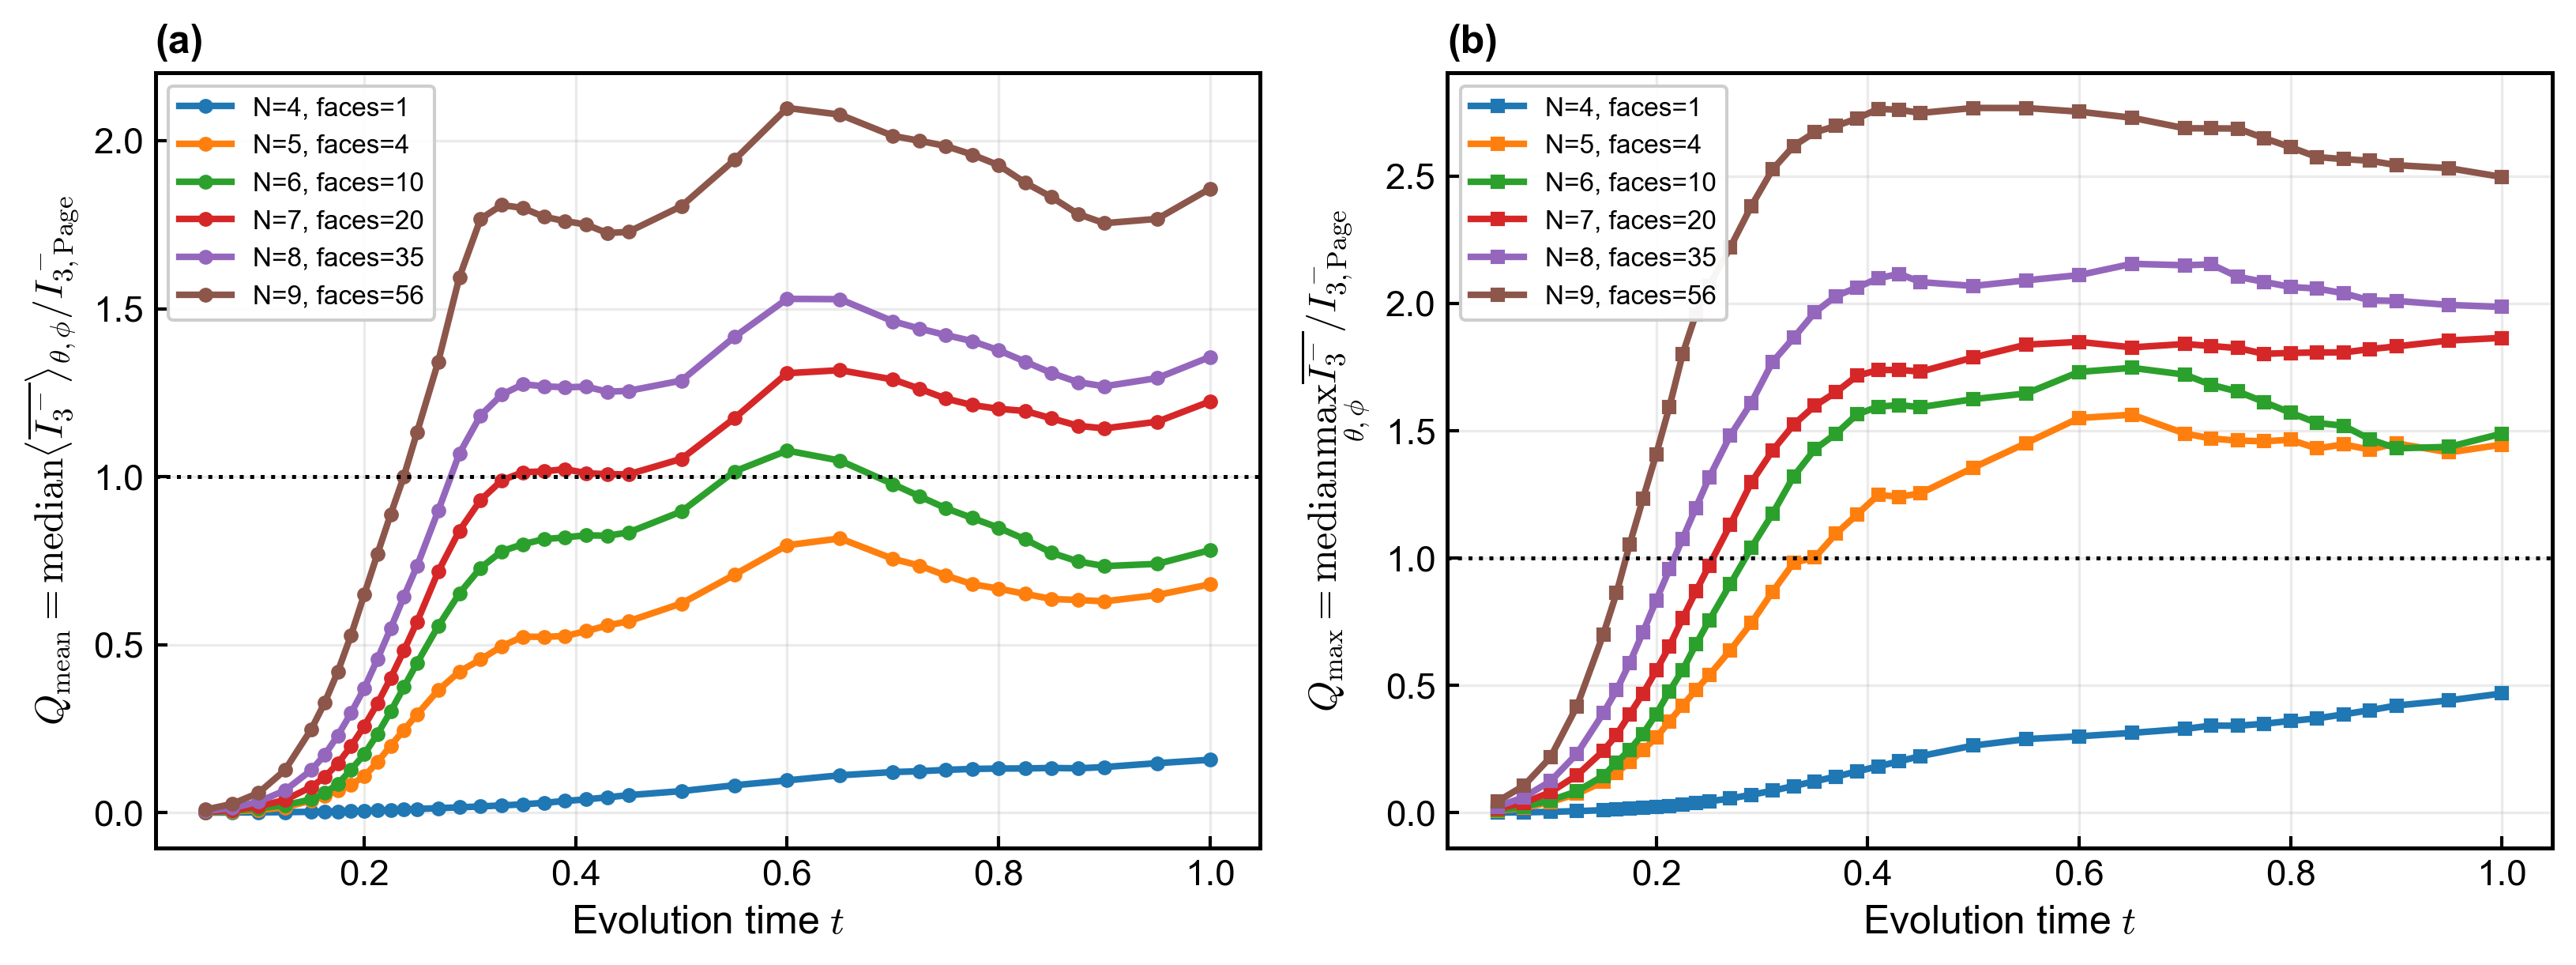

Saved: finite_size_Page_normalized_I3minus.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharex=True)

ax1, ax2 = axes

for N in Ns:
    sub = stats_t[stats_t["N"] == N].sort_values("t")
    label = f"N={int(N)}, faces={int(sub['N_faces'].iloc[0])}"

    ax1.plot(
        sub["t"], sub["Q_mean_med"],
        "-o", markersize=3.5, linewidth=2.0,
        label=label,
    )

    ax2.plot(
        sub["t"], sub["Q_max_med"],
        "-s", markersize=3.5, linewidth=2.0,
        label=label,
    )

for ax in axes:
    ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
    ax.set_xlabel("Evolution time $t$")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, framealpha=0.95)

ax1.set_title("(a)", loc="left", fontweight="bold")
ax1.set_ylabel(r"$Q_{\rm mean}=\mathrm{median}\langle \overline{I_3^-}\rangle_{\theta,\phi}/I_{3,\rm Page}^-$")

ax2.set_title("(b)", loc="left", fontweight="bold")
ax2.set_ylabel(r"$Q_{\rm max}=\mathrm{median}\max_{\theta,\phi}\overline{I_3^-}/I_{3,\rm Page}^-$")

fig.tight_layout()

save_path = "finite_size_Page_normalized_I3minus.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

In [36]:
# ============================================================
# 6. Finite-size summary over a common late-time window
# ============================================================

t_min, t_max = 0.55, 1.00

scaling_rows = []

for N in Ns:
    sub = stats_t[
        (stats_t["N"] == N)
        & (stats_t["t"] >= t_min)
        & (stats_t["t"] <= t_max)
    ].copy()

    if sub.empty:
        continue

    scaling_rows.append({
        "N": int(N),
        "N_faces": int(sub["N_faces"].iloc[0]),
        "n_states": int(sub["n_states"].max()),
        "Page_I3_minus": float(sub["I3_minus_Page"].iloc[0]),

        "late_corr_Jtot_med": float(np.median(sub["corr_Jtot_med"])),
        "late_corr_Jrho_med": float(np.median(sub["corr_Jrho_med"])),

        "late_corr_Jtot_iqr_med": float(np.median(sub["corr_Jtot_iqr"])),
        "late_corr_Jrho_iqr_med": float(np.median(sub["corr_Jrho_iqr"])),

        "peak_Q_mean": float(np.max(stats_t[stats_t["N"] == N]["Q_mean_med"])),
        "t_peak_Q_mean": float(
            stats_t.loc[stats_t[stats_t["N"] == N]["Q_mean_med"].idxmax(), "t"]
        ),

        "peak_Q_max": float(np.max(stats_t[stats_t["N"] == N]["Q_max_med"])),
        "t_peak_Q_max": float(
            stats_t.loc[stats_t[stats_t["N"] == N]["Q_max_med"].idxmax(), "t"]
        ),
    })

scaling_df = pd.DataFrame(scaling_rows).sort_values("N")
display(scaling_df)

scaling_df.to_csv("finite_size_scaling_summary.csv", index=False)
print("Saved: finite_size_scaling_summary.csv")

,N,N_faces,n_states,Page_I3_minus,late_corr_Jtot_med,late_corr_Jrho_med,late_corr_Jtot_iqr_med,late_corr_Jrho_iqr_med,peak_Q_mean,t_peak_Q_mean,peak_Q_max,t_peak_Q_max
0,4,1,50,0.527593,0.511471,0.241116,0.241244,0.305351,0.157438,1.00,0.468657,1.00
1,5,4,50,0.529076,0.708392,0.527265,0.169163,0.258242,0.816210,0.65,1.563439,0.65
2,6,10,50,0.303528,0.820012,0.703772,0.089090,0.123240,1.077635,0.60,1.747250,0.65
3,7,20,50,0.151961,0.861762,0.743372,0.063807,0.130850,1.316912,0.65,1.864952,1.00
4,8,35,50,0.076030,0.846404,0.779167,0.048749,0.075385,1.529163,0.60,2.155714,0.65
5,9,56,50,0.038027,0.787099,0.711053,0.062821,0.091819,2.097381,0.60,2.767785,0.50


Saved: finite_size_scaling_summary.csv
